## 1. Loading and Inspecting the Dataset

First, we load the e-commerce dataset and display the first few records.

This helps us understand what type of information is available in the dataset before deciding the Machine Learning problem.

We will not assume the target variable at this stage. We will inspect the actual columns and their values first.

In [1]:
# Load the e-commerce dataset

import pandas as pd
import numpy as np

df = pd.read_csv('ecommerce_customer.csv')

# Display the first 5 rows
df.head()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


## 2. Understanding the Dataset Shape

Now we check the number of rows and columns in the dataset.

- Rows represent individual records in the e-commerce dataset.
- Columns represent different customer, order, product, sales, and other attributes.

This helps us understand the overall size of the dataset before performing further analysis.

In [2]:
# Check the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 3055
Number of columns: 32
Dataset shape: (3055, 32)


## 3. Understanding Column Information

Now we will use `info()` to understand the structure of every column.

This tells us:
- Column names
- Number of non-null values
- Data types such as integer, decimal, or text

This is important because later we need to identify numerical and categorical features and handle them correctly during preprocessing.

In [3]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 3055 non-null   object 
 1   Customer_ID              3055 non-null   object 
 2   Order_Date               3055 non-null   object 
 3   Customer_Age             2932 non-null   float64
 4   Customer_Segment         3055 non-null   object 
 5   City                     2979 non-null   object 
 6   Region                   3055 non-null   object 
 7   Category                 3055 non-null   object 
 8   Product_Name             3055 non-null   object 
 9   Sales_Channel            3055 non-null   object 
 10  Payment_Method           2978 non-null   object 
 11  Device                   3055 non-null   object 
 12  Quantity                 3055 non-null   int64  
 13  Unit_Price               2962 non-null   float64
 14  Discount_Pct            

## 4. Checking Missing Values

Now we check how many missing values are present in each column.

Missing values can cause problems during Machine Learning because most models cannot directly work with empty values.

We will first understand where the missing values are and how many there are. We will decide the appropriate treatment during preprocessing instead of removing data unnecessarily.

In [4]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Customer_Age               123
City                        76
Payment_Method              77
Unit_Price                  93
Discount_Pct               153
Shipping_Days              107
Customer_Rating            215
Customer_Loyalty_Points    125
Website_Session_Minutes     76
Customer_Satisfaction      154
Gross_Amount                93
Discount_Amount            245
Net_Sales                  245
Estimated_Cost             245
Profit                     245
Profit_Margin_Pct          246
dtype: int64

Total missing values: 2518


## 5. Checking Duplicate Records

Now we check whether the dataset contains completely duplicated rows.

Duplicate records can give extra importance to the same observation and may affect Machine Learning model performance.

We will identify the number of duplicates first and decide what to do with them later.

In [5]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 50


## 6. Statistical Summary of Numerical Columns

Now we examine the statistical summary of the numerical columns.

This gives us information such as:
- Count
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This helps us understand the distribution of the numerical data and identify values that may need further investigation during EDA, such as possible outliers.

In [6]:
# Display statistical summary of numerical columns

df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,2932.000000,3055.000000,2962.00000,2902.000000,2948.000000,2840.000000,3055.000000,2930.000000,2979.000000,3055.000000,3055.000000,2901.000000,2962.000000,2810.000000,2810.000000,2810.000000,2810.000000,2809.000000
mean,35.328104,3.248773,1583.13266,15.407105,4.550543,3.745070,3.673355,872.558362,14.699094,7.062848,5.006219,3.669424,5171.610665,786.158598,4411.498904,3153.257843,1258.241060,28.377437
std,11.316398,1.861875,2366.58516,10.502571,2.288896,0.777563,0.838132,629.154614,9.540359,2.678465,2.276333,0.842385,8994.240302,1681.951220,7595.452348,5346.688134,2529.055858,9.427132
min,-13.000000,-2.000000,12.75000,-10.000000,-3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-7620.860000,-780.380000,-6840.480000,-5446.480000,-1394.000000,12.040000
25%,28.000000,2.000000,468.92250,8.250000,3.000000,3.200000,3.100000,363.000000,7.900000,5.000000,3.000000,3.100000,1214.615000,107.150000,1020.622500,723.547500,263.065000,20.280000
50%,35.000000,3.000000,923.14500,14.895000,4.000000,3.800000,3.700000,834.500000,12.700000,7.000000,5.000000,3.700000,2640.185000,327.825000,2286.520000,1613.435000,611.055000,28.230000
75%,42.250000,4.000000,1878.94250,21.670000,6.000000,4.300000,4.300000,1294.000000,19.450000,9.000000,6.000000,4.300000,5730.980000,834.957500,4841.167500,3504.470000,1318.835000,36.400000
max,102.000000,40.000000,61182.50000,120.000000,35.000000,9.000000,5.000000,2970.000000,96.100000,18.000000,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000


## 7. Identifying Numerical and Categorical Columns

Now we separate the columns into two groups:

- Numerical columns contain values that can be used for mathematical calculations.
- Categorical columns contain text or categories.

This is important because Machine Learning models handle numerical and categorical data differently. Later, categorical columns will need appropriate encoding before modeling.

In [7]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nNumber of Numerical Columns:", len(numerical_columns))

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumber of Categorical Columns:", len(categorical_columns))

Numerical Columns:
['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit', 'Profit_Margin_Pct']

Number of Numerical Columns: 18

Categorical Columns:
['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Return_Status', 'Order_Status', 'Marketing_Source']

Number of Categorical Columns: 14


## 8. Checking Unique Values in Categorical Columns

Now we check the number of unique values in each categorical column.

This helps us understand the different categories present in the e-commerce data.

It is especially important before encoding because:
- Some columns may have only a few categories.
- Some columns may have many categories.
- Identifier columns such as Order_ID may contain mostly unique values.

We will use this information later to decide which categorical features are suitable for Machine Learning.

In [8]:
# Check the number of unique values in categorical columns

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Order_ID: 3000 unique values
Customer_ID: 776 unique values
Order_Date: 365 unique values
Customer_Segment: 4 unique values
City: 20 unique values
Region: 5 unique values
Category: 16 unique values
Product_Name: 10 unique values
Sales_Channel: 4 unique values
Payment_Method: 11 unique values
Device: 4 unique values
Return_Status: 2 unique values
Order_Status: 5 unique values
Marketing_Source: 5 unique values


## 9. Inspecting the Actual Categories

Now we will display the unique values of each categorical column.

This helps us understand what the categories actually represent instead of looking only at their counts.

This is useful for identifying:
- Different customer segments
- Regions and cities
- Product categories
- Sales channels
- Payment methods
- Return and order statuses
- Marketing sources

We will use these actual values to guide our preprocessing and EDA.

In [9]:
# Display unique values of each categorical column

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique())


Order_ID:
['ORD100994' 'ORD101072' 'ORD100995' ... 'ORD101767' 'ORD101123'
 'ORD101347']

Customer_ID:
['C1229' 'C1627' 'C1410' 'C1578' 'C1524' 'C1532' 'C1210' 'C1762' 'C1619'
 'C1501' 'C1339' 'C1204' 'C1430' 'C1110' 'C1728' 'C1212' 'C1552' 'C1784'
 'C1680' 'C1544' 'C1580' 'C1667' 'C1302' 'C1645' 'C1443' 'C1357' 'C1049'
 'C1147' 'C1252' 'C1599' 'C1149' 'C1560' 'C1307' 'C1243' 'C1439' 'C1080'
 'C1300' 'C1548' 'C1213' 'C1105' 'C1617' 'C1482' 'C1681' 'C1588' 'C1365'
 'C1113' 'C1164' 'C1491' 'C1107' 'C1191' 'C1282' 'C1502' 'C1457' 'C1432'
 'C1198' 'C1128' 'C1071' 'C1790' 'C1719' 'C1435' 'C1165' 'C1516' 'C1775'
 'C1015' 'C1350' 'C1732' 'C1572' 'C1486' 'C1378' 'C1007' 'C1739' 'C1470'
 'C1633' 'C1431' 'C1395' 'C1205' 'C1237' 'C1478' 'C1073' 'C1576' 'C1725'
 'C1087' 'C1111' 'C1328' 'C1564' 'C1381' 'C1711' 'C1273' 'C1412' 'C1137'
 'C1020' 'C1740' 'C1112' 'C1313' 'C1267' 'C1706' 'C1584' 'C1135' 'C1316'
 'C1445' 'C1100' 'C1077' 'C1227' 'C1352' 'C1089' 'C1155' 'C1391' 'C1664'
 'C1264' 'C1427' 'C1

## 10. Checking the Distribution of Numerical Features

Now we will visualize the distribution of the numerical columns.

Histograms help us understand how the numerical values are distributed.

They can help us identify:
- Skewed data
- Unusual values
- Concentration of values
- Possible outliers

We will use these observations later when deciding how to preprocess the data. We will not remove values only because they look unusual; we will investigate them first.

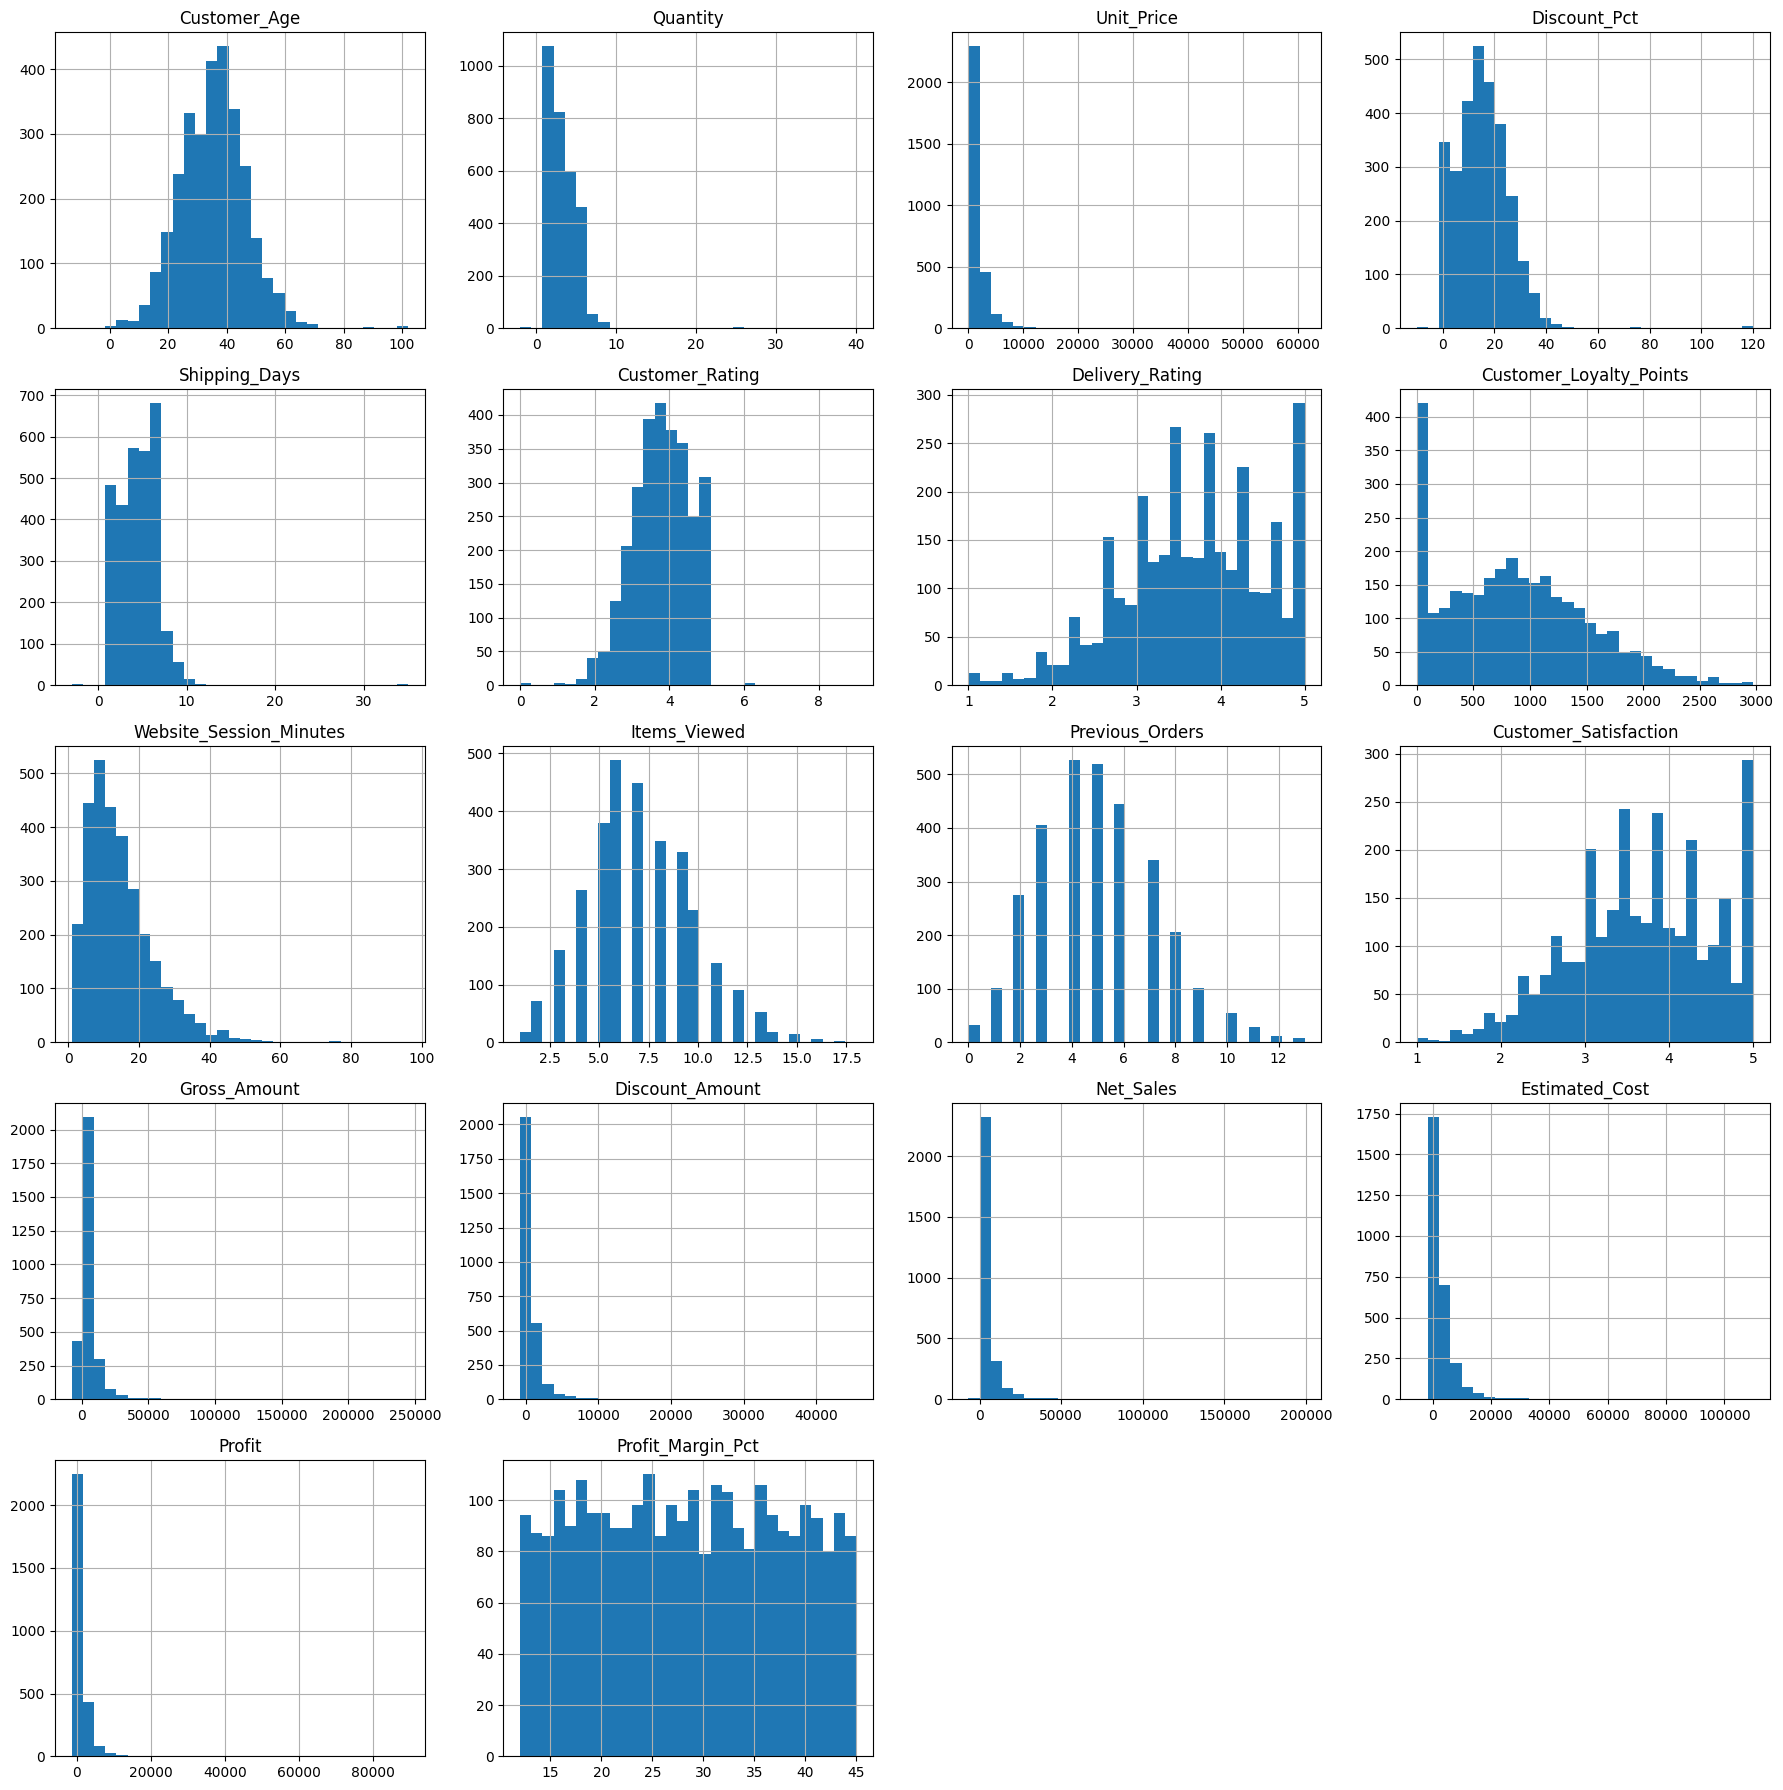

In [10]:
# Plot distributions of numerical columns

import matplotlib.pyplot as plt

df[numerical_columns].hist(
    figsize=(18, 18),
    bins=30
)

plt.tight_layout()
plt.show()

## 11. Checking for Possible Outliers

Now we will identify possible outliers in the numerical columns using the IQR (Interquartile Range) method.

The IQR method checks values that are unusually far from the middle 50% of the data.

This does not mean that every detected value is wrong. In an e-commerce dataset, large orders, high prices, or high profits can be genuine.

Therefore, we will identify the possible outliers first and decide later whether any treatment is actually necessary.

In [11]:
# Check possible outliers using the IQR method

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()

    outlier_summary.append([col, outliers, lower_bound, upper_bound])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Possible_Outliers", "Lower_Bound", "Upper_Bound"]
)

outlier_df.sort_values(
    by="Possible_Outliers",
    ascending=False
)

,Column,Possible_Outliers,Lower_Bound,Upper_Bound
12,Gross_Amount,291,-5559.93250,12505.52750
16,Profit,291,-1320.59000,2902.49000
14,Net_Sales,278,-4710.19500,10571.98500
15,Estimated_Cost,270,-3447.83625,7675.85375
13,Discount_Amount,264,-984.56125,1926.66875
2,Unit_Price,228,-1646.10750,3993.97250
8,Website_Session_Minutes,86,-9.42500,36.77500
10,Previous_Orders,49,-1.50000,10.50000
0,Customer_Age,42,6.62500,63.62500
1,Quantity,36,-1.00000,7.00000


## 12. Checking Correlation Between Numerical Features

Now we will examine the correlation between numerical variables.

Correlation helps us understand how strongly two numerical variables move together.

This is useful for:
- Understanding relationships between features
- Finding features that may have a relationship with possible target variables
- Identifying highly related variables

We will use correlation as an EDA tool, not as the only reason to remove a feature. If a feature appears weak, we will later test its actual effect on model performance.

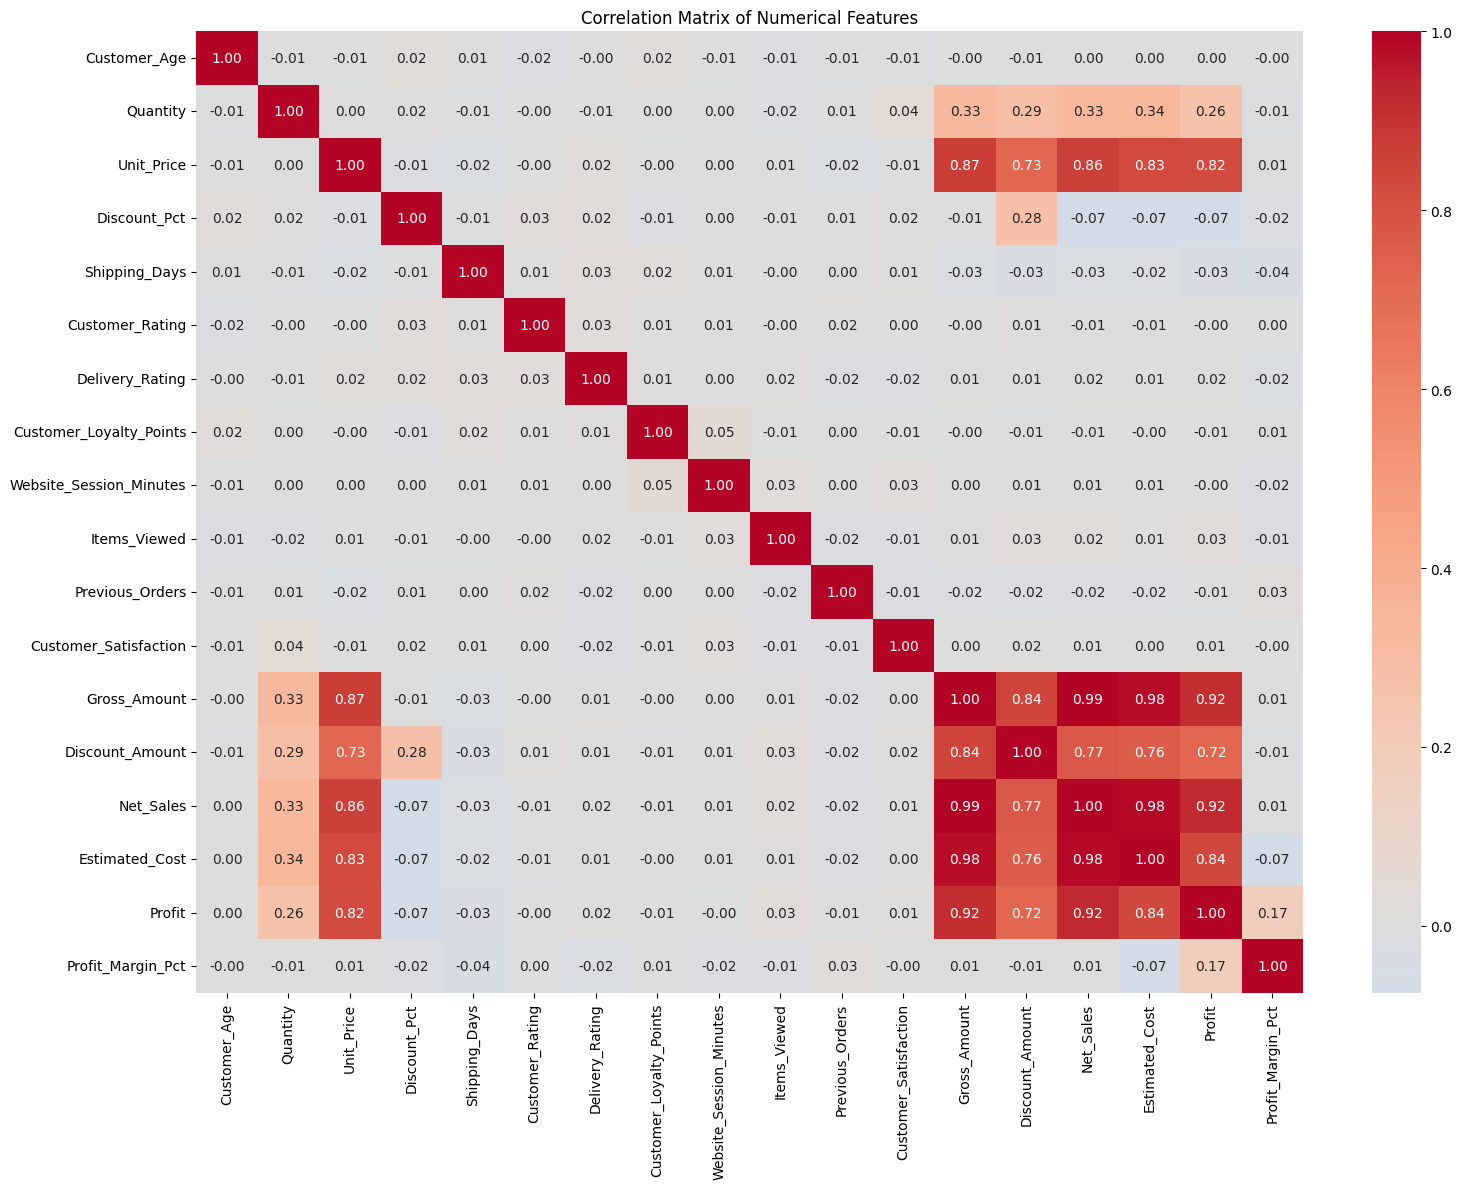

In [12]:
# Calculate and visualize the correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 13. Exploring Categorical Features

Now we will examine how frequently each category appears in the dataset.

This helps us understand the distribution of categorical variables such as customer segment, region, category, sales channel, payment method, and order status.

It also helps us identify categories that have very few observations, which can be important when preparing the data for Machine Learning.

We will use the actual distributions from this dataset to decide which features are useful.

In [13]:
# Display frequency counts for all categorical columns

for col in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{col}")
    print(f"{'=' * 50}")
    print(df[col].value_counts(dropna=False))


Order_ID
Order_ID
ORD100053    2
ORD100045    2
ORD101818    2
ORD102604    2
ORD100473    2
            ..
ORD102750    1
ORD101157    1
ORD102649    1
ORD102180    1
ORD100121    1
Name: count, Length: 3000, dtype: int64

Customer_ID
Customer_ID
C1744    10
C1418    10
C1423     9
C1790     9
C1282     9
         ..
C1749     1
C1186     1
C1043     1
C1039     1
C1772     1
Name: count, Length: 776, dtype: int64

Order_Date
Order_Date
2025-12-08    21
2025-06-02    17
2025-11-07    16
2025-06-08    16
2025-12-18    15
              ..
2025-12-11     2
2025-07-06     2
2025-04-10     2
2025-11-25     2
2025-08-23     2
Name: count, Length: 365, dtype: int64

Customer_Segment
Customer_Segment
Regular       1487
Occasional     661
Premium        529
New            378
Name: count, dtype: int64

City
City
Chennai       308
Kochi         299
Delhi         296
Coimbatore    295
Kolkata       293
Mumbai        291
Hyderabad     290
Pune          281
Bengaluru     278
Jaipur        257
NaN

## 14. Understanding the Order Date

Now we will examine the `Order_Date` column.

The column is currently stored as text, so we need to understand its date range and format.

Dates can provide useful information such as year, month, day, and seasonality. This may become useful during EDA and may also help us create meaningful features for Machine Learning.

We will first inspect the date range before deciding how to use it.

In [14]:
# Convert Order_Date to datetime for inspection

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

print("Minimum Order Date:", df['Order_Date'].min())
print("Maximum Order Date:", df['Order_Date'].max())

print("\nNumber of invalid/missing dates:", df['Order_Date'].isna().sum())

print("\nSample dates:")
print(df['Order_Date'].head())

Minimum Order Date: 2025-01-01 00:00:00
Maximum Order Date: 2025-12-31 00:00:00

Number of invalid/missing dates: 0

Sample dates:
0   2025-06-07
1   2025-03-18
2   2025-07-13
3   2025-09-24
4   2025-06-09
Name: Order_Date, dtype: datetime64[ns]


## 15. Analyzing Order Trends Over Time

Since the dataset contains orders throughout 2025, we will check how the number of orders changes from month to month.

This helps us understand whether there is any noticeable seasonal or monthly pattern in the e-commerce data.

This is part of EDA and will help us understand the business behavior before selecting the Machine Learning target.

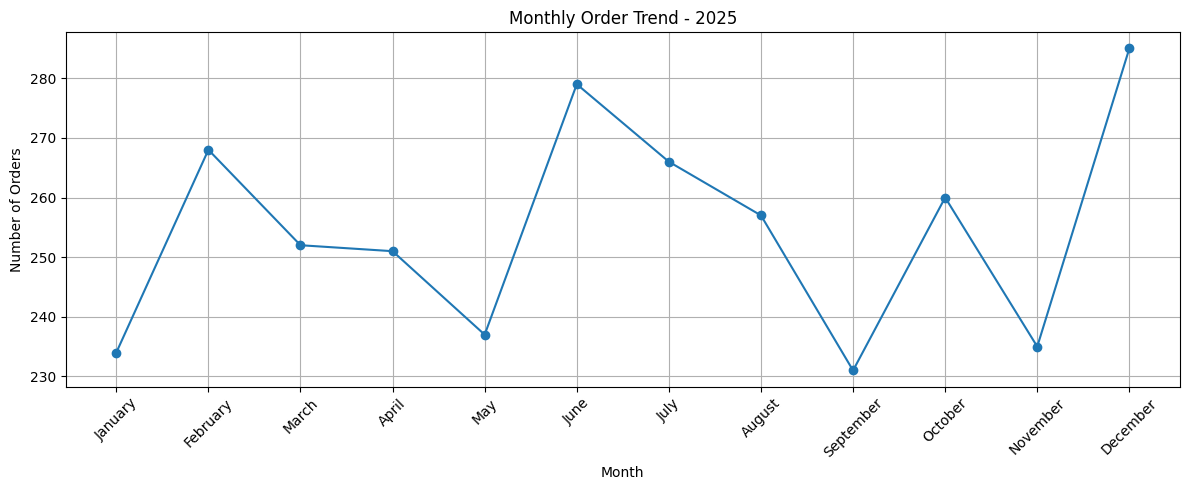

In [15]:
# Analyze monthly order trends

monthly_orders = (
    df.groupby(df['Order_Date'].dt.month)
      .size()
)

# Convert month numbers to month names
monthly_orders.index = pd.to_datetime(
    monthly_orders.index,
    format='%m'
).month_name()

plt.figure(figsize=(12, 5))

monthly_orders.plot(kind='line', marker='o')

plt.title("Monthly Order Trend - 2025")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(12), monthly_orders.index, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Comparing Possible Target Variables

Before creating the problem statement, we will examine some possible numerical target variables.

A good target should:
- Represent a meaningful business outcome
- Have enough valid observations
- Be something we can realistically predict from other features
- Avoid using information that is directly calculated from the target

We will compare important continuous variables such as sales, profit, customer satisfaction, and ratings.

This step helps us choose the Machine Learning problem based on the actual dataset instead of assuming a target.

In [16]:
# Compare possible continuous target variables

possible_targets = [
    'Net_Sales',
    'Profit',
    'Profit_Margin_Pct',
    'Customer_Satisfaction',
    'Customer_Rating',
    'Delivery_Rating'
]

target_summary = df[possible_targets].agg(
    ['count', 'mean', 'std', 'min', 'max']
).T

target_summary['missing_values'] = df[possible_targets].isnull().sum()

target_summary

,count,mean,std,min,max,missing_values
Net_Sales,2810.0,4411.498904,7595.452348,-6840.48,199210.22,245
Profit,2810.0,1258.241060,2529.055858,-1394.00,89404.00,245
Profit_Margin_Pct,2809.0,28.377437,9.427132,12.04,44.98,246
Customer_Satisfaction,2901.0,3.669424,0.842385,1.00,5.00,154
Customer_Rating,2840.0,3.745070,0.777563,0.00,9.00,215
Delivery_Rating,3055.0,3.673355,0.838132,1.00,5.00,0


## 17. Final Problem Statement

### Problem Statement

The objective of this project is to predict the **Profit** generated from an e-commerce transaction using available customer, product, order, marketing, and operational information.

### Target Variable (Y)

**Profit**

Profit is a continuous numerical variable, so this is a **Regression problem**.

### Independent Variables (X)

The input features will be selected from the available customer, product, order, marketing, and operational information.

Financial variables that directly represent or are closely derived from the target will be carefully excluded to avoid data leakage.

### Why This Problem?

Profit is an important business outcome because it shows the financial result of an e-commerce transaction.

By predicting Profit, we can compare different Machine Learning algorithms and understand how well the available transaction and customer information can explain profit.

In [17]:
# Check the selected target variable

target = 'Profit'

print("Selected Target Variable:", target)
print("Target Data Type:", df[target].dtype)
print("Number of Valid Values:", df[target].notna().sum())
print("Number of Missing Values:", df[target].isna().sum())

print("\nProfit Statistics:")
print(df[target].describe())

Selected Target Variable: Profit
Target Data Type: float64
Number of Valid Values: 2810
Number of Missing Values: 245

Profit Statistics:
count     2810.000000
mean      1258.241060
std       2529.055858
min      -1394.000000
25%        263.065000
50%        611.055000
75%       1318.835000
max      89404.000000
Name: Profit, dtype: float64


## 18. Removing Duplicate Records

We previously found 50 completely duplicated rows.

Duplicate rows represent repeated copies of the same observation. Keeping them could give those transactions extra influence during Machine Learning.

Therefore, we will remove the exact duplicate rows before further preprocessing.

We are only removing exact duplicates, not similar or unusual transactions.

In [18]:
# Remove exact duplicate rows

print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))
print("Duplicates remaining:", df.duplicated().sum())

Rows before removing duplicates: 3055
Rows after removing duplicates: 3005
Duplicates remaining: 0


## 19. Handling Missing Values in the Target

The target variable is `Profit`.

Rows where Profit is missing cannot be used for supervised Machine Learning because the model needs a known target value to learn from.

Therefore, instead of filling the missing Profit values with an estimated number, we will remove only the rows where the target is missing.

We will not remove rows just because a feature has a missing value. Feature missing values will be handled separately in the next step.

This keeps the target reliable and avoids introducing artificial Profit values.

In [19]:
# Remove rows where the target variable (Profit) is missing

print("Rows before removing missing Profit:", len(df))
print("Missing Profit values:", df['Profit'].isna().sum())

df = df.dropna(subset=['Profit']).copy()

print("\nRows after removing missing Profit:", len(df))
print("Missing Profit values remaining:", df['Profit'].isna().sum())

Rows before removing missing Profit: 3005
Missing Profit values: 240

Rows after removing missing Profit: 2765
Missing Profit values remaining: 0


## 20. Checking Missing Values in Predictor Variables

After removing rows with missing Profit, some predictor variables still contain missing values.

We will first check the remaining missing values.

We will not fill them blindly. In the next preprocessing step, numerical and categorical variables will be handled differently, and the imputation will be performed using the training data to avoid data leakage.

In [20]:
# Check remaining missing values in all columns

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Remaining columns with missing values:")
print(missing_values)

print("\nTotal missing values remaining:", missing_values.sum())

Remaining columns with missing values:
Customer_Rating            195
Customer_Satisfaction      130
Customer_Age               114
Customer_Loyalty_Points    112
Shipping_Days               99
Website_Session_Minutes     72
City                        71
Payment_Method              66
Profit_Margin_Pct            1
dtype: int64

Total missing values remaining: 860


## 21. Standardizing Categorical Values

The `Payment_Method` column contains the same payment methods with different capitalization.

For example:
- Cash
- CASH
- Net Banking
- NET BANKING

These should be treated as the same category.

We will standardize the text formatting before encoding categorical variables.

This prevents the Machine Learning model from treating different spellings of the same category as separate values.

In [21]:
# Standardize Payment_Method values

print("Payment methods before standardization:")
print(df['Payment_Method'].value_counts(dropna=False))

# Convert non-missing values to uppercase and remove extra spaces
df['Payment_Method'] = df['Payment_Method'].str.strip().str.upper()

print("\nPayment methods after standardization:")
print(df['Payment_Method'].value_counts(dropna=False))

Payment methods before standardization:
Payment_Method
UPI            495
Net Banking    457
Credit Card    439
Debit Card     434
Cash           424
Wallet         417
NaN             66
CASH            11
NET BANKING     10
WALLET           5
CREDIT CARD      4
DEBIT CARD       3
Name: count, dtype: int64

Payment methods after standardization:
Payment_Method
UPI            495
NET BANKING    467
CREDIT CARD    443
DEBIT CARD     437
CASH           435
WALLET         422
NaN             66
Name: count, dtype: int64


## 22. Extracting Useful Features from Order Date

`Order_Date` contains transaction dates.

Instead of directly using the complete date as a categorical variable, we will extract useful information from it:

- Year
- Month
- Day
- Day of Week

These features can help the model learn whether transaction timing is related to Profit.

The original `Order_Date` column will not be directly used as a categorical feature.

In [22]:
# Create useful features from Order_Date

df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_DayOfWeek'] = df['Order_Date'].dt.dayofweek

print("New date-based features created:")
print(df[['Order_Date', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_DayOfWeek']].head())

print("\nUnique values:")
print("Year:", df['Order_Year'].nunique())
print("Month:", df['Order_Month'].nunique())
print("Day:", df['Order_Day'].nunique())
print("Day of Week:", df['Order_DayOfWeek'].nunique())

New date-based features created:
  Order_Date  Order_Year  Order_Month  Order_Day  Order_DayOfWeek
0 2025-06-07        2025            6          7                5
2 2025-07-13        2025            7         13                6
3 2025-09-24        2025            9         24                2
4 2025-06-09        2025            6          9                0
5 2025-02-10        2025            2         10                0

Unique values:
Year: 1
Month: 12
Day: 31
Day of Week: 7


## 23. Identifying Target Leakage and Unnecessary Columns

Our target variable is `Profit`.

Some columns contain information that is directly derived from Profit or are components of the financial calculation.

We will exclude these columns from the predictors:

- Profit → Target variable
- Profit_Margin_Pct → directly related to Profit
- Net_Sales → directly used in calculating Profit
- Estimated_Cost → directly used in calculating Profit
- Gross_Amount → part of the sales calculation
- Discount_Amount → used to calculate Net Sales
- Order_ID → transaction identifier
- Customer_ID → customer identifier
- Order_Date → replaced by extracted date features
- Order_Year → constant because all transactions are from 2025

We will keep other customer, product, order, marketing, and operational variables because they can potentially help predict Profit.

We will not remove weak predictors at this stage. Their effect will be tested later using the same feature set across models.

In [23]:
# Define columns that should not be used as predictors

excluded_columns = [
    'Profit',
    'Profit_Margin_Pct',
    'Net_Sales',
    'Estimated_Cost',
    'Gross_Amount',
    'Discount_Amount',
    'Order_ID',
    'Customer_ID',
    'Order_Date',
    'Order_Year'
]

# Create predictor dataset
X = df.drop(columns=excluded_columns)
y = df['Profit']

print("Predictor columns:")
print(X.columns.tolist())

print("\nNumber of predictor columns:", X.shape[1])
print("Number of rows:", X.shape[0])

print("\nTarget variable:", y.name)
print("Target rows:", len(y))

Predictor columns:
['Customer_Age', 'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Return_Status', 'Order_Status', 'Marketing_Source', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Order_Month', 'Order_Day', 'Order_DayOfWeek']

Number of predictor columns: 26
Number of rows: 2765

Target variable: Profit
Target rows: 2765


## 24. Checking Predictor Data Types

Before preprocessing the predictors, we need to separate them into:

- Numerical features → missing-value handling + scaling
- Categorical features → missing-value handling + encoding

We will inspect the data types of our 26 predictor variables before building the preprocessing pipeline.

In [24]:
# Check data types of predictor variables

print("Numerical predictor columns:")
print(X.select_dtypes(include='number').columns.tolist())

print("\nNumber of numerical predictors:",
      X.select_dtypes(include='number').shape[1])

print("\nCategorical predictor columns:")
print(X.select_dtypes(include='object').columns.tolist())

print("\nNumber of categorical predictors:",
      X.select_dtypes(include='object').shape[1])

Numerical predictor columns:
['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Order_Month', 'Order_Day', 'Order_DayOfWeek']

Number of numerical predictors: 15

Categorical predictor columns:
['Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Return_Status', 'Order_Status', 'Marketing_Source']

Number of categorical predictors: 11


## 25. Train-Test Split

We will divide the dataset into:

- 80% Training data → used to train the models
- 20% Testing data → used to evaluate the models

The test data must remain unseen during preprocessing and model training.

We will use `random_state=34` so that the same split can be reproduced every time.

The preprocessing steps such as imputation, encoding, and scaling will be fitted only on the training data.

In [25]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    random_state=34
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (2212, 26)
y_train: (2212,)

Testing data:
X_test: (553, 26)
y_test: (553,)


## 26. Building the Preprocessing Pipeline

Our dataset contains both numerical and categorical features.

### Numerical features
We will:
1. Fill missing values using the median.
2. Standardize the values using StandardScaler.

### Categorical features
We will:
1. Fill missing values using the most frequent category.
2. Convert categories into numerical values using One-Hot Encoding.

The preprocessing will be fitted only on the training data.

This prevents information from the test dataset from influencing the training process and helps avoid data leakage.

The same preprocessing will then be applied to the test data.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Preprocessing pipeline created successfully.")

Numerical features: 15
Categorical features: 11
Preprocessing pipeline created successfully.


## 27. Applying the Preprocessing Pipeline

We will now apply the preprocessing steps to our data.

The preprocessor will:

- Learn numerical imputation values from `X_train`
- Learn categorical imputation values from `X_train`
- Learn categorical encoding from `X_train`
- Learn numerical scaling from `X_train`

Then the same learned transformations will be applied to `X_test`.

This ensures that the test data remains unseen during the learning process.

In [27]:
# Fit the preprocessor using training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same preprocessing to test data
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

print("\nPreprocessing completed successfully.")

Training data after preprocessing: (2212, 96)
Testing data after preprocessing: (553, 96)

Preprocessing completed successfully.


## 28. Linear Regression Model

Linear Regression is our baseline regression model.

It tries to learn the relationship between the input features and the continuous target variable, `Profit`.

The model learns coefficients for the features and uses them to predict Profit.

We will train the model using the preprocessed training data and then predict Profit for the unseen test data.

The model will be evaluated using:

- MAE → average prediction error
- MSE → squared prediction error
- RMSE → error in the original Profit scale
- R² Score → how much variation in Profit is explained by the model

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluate the model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 615.2282497567602
MSE : 1169602.562874137
RMSE: 1081.4816516585647
R²  : 0.7437879003120571


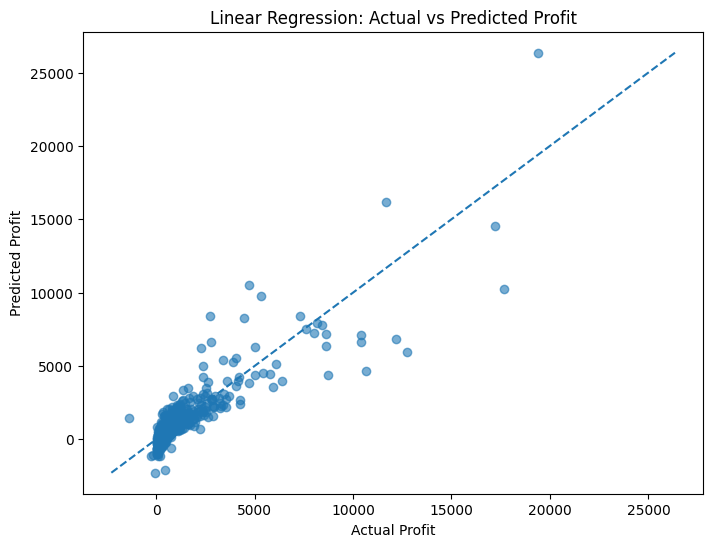

In [29]:
import matplotlib.pyplot as plt

# Actual vs Predicted Profit
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

# Reference line: perfect prediction
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Linear Regression: Actual vs Predicted Profit")
plt.show()

## 30. KNN Regression

K-Nearest Neighbors (KNN) Regression predicts Profit by looking at the most similar observations in the training data.

For each test observation, KNN:
1. Finds the nearest training observations.
2. Looks at their Profit values.
3. Uses their values to predict the Profit of the new observation.

KNN depends on distance between observations, so feature scaling is important.

We will use the same preprocessed training and testing data used for Linear Regression.

In [30]:
from sklearn.neighbors import KNeighborsRegressor

# Create KNN Regression model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_knn = knn_model.predict(X_test_processed)

# Evaluate the model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Results")
print("----------------------")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R²  :", r2_knn)

KNN Regression Results
----------------------
MAE : 761.1752983725136
MSE : 2269866.2462082463
RMSE: 1506.6075289232583
R²  : 0.5027651140549123


## 31. Decision Tree Regression

Decision Tree Regression predicts Profit by creating a series of decision rules based on the input features.

The tree repeatedly splits the data into smaller groups so that observations with similar Profit values are grouped together.

Unlike Linear Regression, a Decision Tree can model non-linear relationships.

We will train it using the same preprocessed training data and evaluate it using MAE, MSE, RMSE, and R².

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree Regression model
tree_model = DecisionTreeRegressor(random_state=34)

# Train the model
tree_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_tree = tree_model.predict(X_test_processed)

# Evaluate the model
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Results")
print("--------------------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Regression Results
--------------------------------
MAE : 544.4919891500904
MSE : 1732436.3101278478
RMSE: 1316.2204641046453
R²  : 0.620494039015496


## 32. Support Vector Regression (SVR)

Support Vector Regression (SVR) is a regression algorithm that tries to find a function that predicts continuous values while keeping prediction errors within a specified tolerance.

SVR can model non-linear relationships when a suitable kernel is used.

Feature scaling is especially important for SVR because it depends on distances and feature magnitudes.

Our numerical features have already been standardized, and the same preprocessed data will be used for SVR.

In [32]:
from sklearn.svm import SVR

# Create SVR model
svr_model = SVR(kernel='rbf')

# Train the model
svr_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_svr = svr_model.predict(X_test_processed)

# Evaluate the model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Results")
print("-----------")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R²  :", r2_svr)

SVR Results
-----------
MAE : 966.4717506421606
MSE : 4908289.19424522
RMSE: 2215.465909068614
R²  : -0.07520547598914407


## 33. Random Forest Regression

Random Forest Regression combines multiple Decision Trees.

Each tree learns from the training data, and the forest combines their predictions to produce the final Profit prediction.

Because many trees are combined, Random Forest can capture non-linear relationships while reducing the instability of a single Decision Tree.

We will use the same training and testing data and evaluate it using MAE, MSE, RMSE, and R².

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Regression model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=34
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_rf = random_forest_model.predict(X_test_processed)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("---------------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
---------------------------------
MAE : 390.9041674502713
MSE : 1014775.9376053698
RMSE: 1007.3608775435791
R²  : 0.7777040834727963


## 34. Bagging Regression

Bagging Regression uses multiple versions of a base regression model and combines their predictions.

Each model is trained using a different random sample of the training data.

The final prediction is obtained by combining the predictions from all models.

Bagging can reduce the effect of variation in individual models and improve prediction stability.

We will evaluate it using the same test data and the same four regression metrics.

In [34]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Create Bagging Regression model
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=34),
    n_estimators=100,
    random_state=34
)

# Train the model
bagging_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_bagging = bagging_model.predict(X_test_processed)

# Evaluate the model
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mse_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print("Bagging Regression Results")
print("--------------------------")
print("MAE :", mae_bagging)
print("MSE :", mse_bagging)
print("RMSE:", rmse_bagging)
print("R²  :", r2_bagging)

Bagging Regression Results
--------------------------
MAE : 395.4838915009041
MSE : 1066924.4705456067
RMSE: 1032.9203602144778
R²  : 0.7662804721159342


### Bagging Regression – Actual vs Predicted

This plot compares the actual Profit values with the Profit values predicted by the Bagging Regression model.

A good model should have the points close to the diagonal line, which means predicted values are close to actual values.

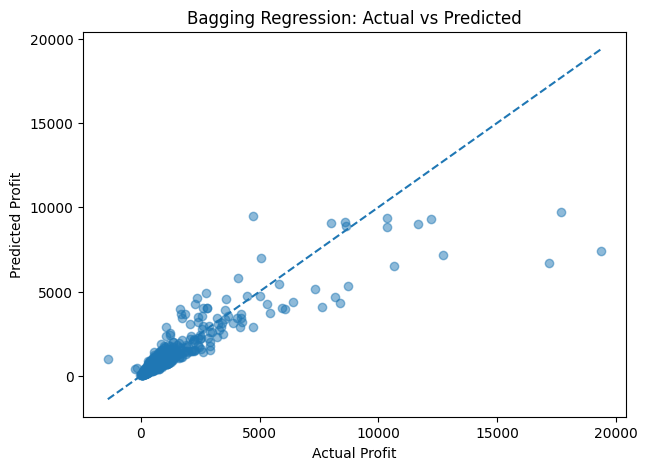

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_bagging, alpha=0.5)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Bagging Regression: Actual vs Predicted")

min_value = min(y_test.min(), y_pred_bagging.min())
max_value = max(y_test.max(), y_pred_bagging.max())

plt.plot([min_value, max_value],
         [min_value, max_value],
         linestyle="--")

plt.show()

### Boosting Regression

Boosting builds multiple weak models one after another.

Each new model tries to improve the errors made by the previous models.

Here we use Gradient Boosting Regression to predict Profit.

We use the same training data, test data, and processed features so the comparison with the other models remains fair.

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

boosting_model = GradientBoostingRegressor(random_state=34)

boosting_model.fit(X_train_processed, y_train)

y_pred_boosting = boosting_model.predict(X_test_processed)

mae_boosting = mean_absolute_error(y_test, y_pred_boosting)
mse_boosting = mean_squared_error(y_test, y_pred_boosting)
rmse_boosting = np.sqrt(mse_boosting)
r2_boosting = r2_score(y_test, y_pred_boosting)

print("Boosting Regression Results")
print("---------------------------")
print("MAE :", mae_boosting)
print("MSE :", mse_boosting)
print("RMSE:", rmse_boosting)
print("R²  :", r2_boosting)

Boosting Regression Results
---------------------------
MAE : 391.8697794103726
MSE : 782715.1150974435
RMSE: 884.711882534333
R²  : 0.828539121354348


### Boosting Regression – Actual vs Predicted

This plot compares the actual Profit values with the Profit values predicted by the Boosting Regression model.

Points closer to the diagonal line indicate that the predicted values are closer to the actual values.

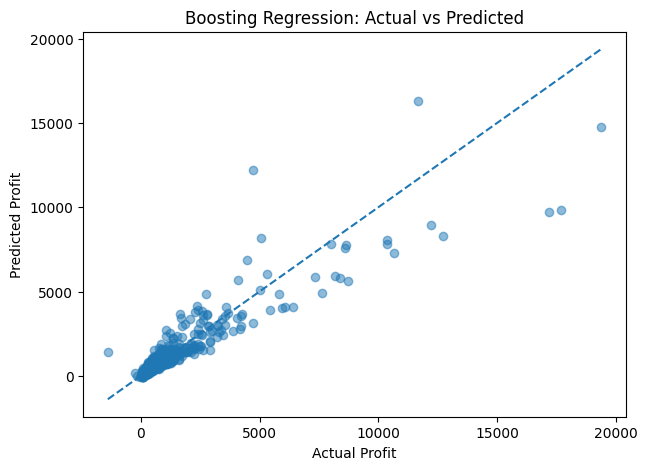

In [37]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_boosting, alpha=0.5)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Boosting Regression: Actual vs Predicted")

min_value = min(y_test.min(), y_pred_boosting.min())
max_value = max(y_test.max(), y_pred_boosting.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

In [38]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regression",
        "Decision Tree Regression",
        "SVR",
        "Random Forest Regression",
        "Bagging Regression",
        "Boosting Regression"
    ],
    "MAE": [
        615.2282497567602,
        761.1752983725136,
        544.4919891500904,
        966.4717506421606,
        390.9041674502713,
        395.4838915009041,
        391.8697794103726
    ],
    "MSE": [
        1169602.562874137,
        2269866.2462082463,
        1732436.3101278478,
        4908289.19424522,
        1014775.9376053698,
        1066924.4705456067,
        782715.1150974435
    ],
    "RMSE": [
        1081.4816516585647,
        1506.6075289232583,
        1316.2204641046453,
        2215.465909068614,
        1007.3608775435791,
        1032.9203602144778,
        884.711882534333
    ],
    "R2": [
        0.7437879003120571,
        0.5027651140549123,
        0.620494039015496,
        -0.07520547598914407,
        0.7777040834727963,
        0.7662804721159342,
        0.828539121354348
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,615.228250,1.169603e+06,1081.481652,0.743788
1,KNN Regression,761.175298,2.269866e+06,1506.607529,0.502765
2,Decision Tree Regression,544.491989,1.732436e+06,1316.220464,0.620494
3,SVR,966.471751,4.908289e+06,2215.465909,-0.075205
4,Random Forest Regression,390.904167,1.014776e+06,1007.360878,0.777704
5,Bagging Regression,395.483892,1.066924e+06,1032.920360,0.766280
6,Boosting Regression,391.869779,7.827151e+05,884.711883,0.828539


## Logistic Regression – Classification Problem

### Problem Statement

The objective of this project is to classify an e-commerce transaction into
Lower Profit or Higher Profit categories based on customer, product, order,
marketing, and operational information.

### Classification Target

The original target variable, Profit, is continuous, so it is used for
regression in the main problem.

For classification, Profit is converted into two categories using the
median Profit as the threshold:

0 = Lower Profit
1 = Higher Profit

This classification problem is created as an additional analysis to
demonstrate Logistic Regression.

The original Profit Prediction problem remains unchanged.

In [39]:
# Create binary classification target using median Profit

profit_threshold = y.median()

y_class = (y >= profit_threshold).astype(int)

print("Profit threshold:", profit_threshold)

print("\nClass distribution:")
print(y_class.value_counts())

print("\nClass meaning:")
print("0 = Lower Profit")
print("1 = Higher Profit")

Profit threshold: 612.14

Class distribution:
Profit
1    1383
0    1382
Name: count, dtype: int64

Class meaning:
0 = Lower Profit
1 = Higher Profit


## Classification Train-Test Split

We split the data into training and testing sets for the classification problem.

80% of the data is used to train the Logistic Regression model.
20% is used to test the model.

Stratification is used so that the Lower Profit and Higher Profit classes
remain balanced in both training and testing data.

The same predictor features used in the regression problem are retained.

In [40]:
from sklearn.model_selection import train_test_split

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X,
    y_class,
    test_size=0.20,
    train_size=0.80,
    random_state=34,
    stratify=y_class
)

print("X_train shape:", X_class_train.shape)
print("X_test shape :", X_class_test.shape)
print("y_train shape:", y_class_train.shape)
print("y_test shape :", y_class_test.shape)

print("\nTraining class distribution:")
print(y_class_train.value_counts())

print("\nTesting class distribution:")
print(y_class_test.value_counts())

X_train shape: (2212, 26)
X_test shape : (553, 26)
y_train shape: (2212,)
y_test shape : (553,)

Training class distribution:
Profit
0    1106
1    1106
Name: count, dtype: int64

Testing class distribution:
Profit
1    277
0    276
Name: count, dtype: int64


## Classification Feature Preprocessing

Logistic Regression requires numerical input.

Our dataset contains both numerical and categorical features.

The preprocessing pipeline will:

- Fill missing numerical values using the median.
- Standardize numerical features.
- Fill missing categorical values using the most frequent value.
- Convert categorical features into numerical values using One-Hot Encoding.

The preprocessing is fitted only on the training data and then applied to both
training and testing data.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

classification_preprocessor = ColumnTransformer([
    (
        "numerical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numerical_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

X_class_train_processed = classification_preprocessor.fit_transform(
    X_class_train
)

X_class_test_processed = classification_preprocessor.transform(
    X_class_test
)

print("Processed training shape:", X_class_train_processed.shape)
print("Processed testing shape :", X_class_test_processed.shape)

Processed training shape: (2212, 96)
Processed testing shape : (553, 96)


## Logistic Regression Model

Logistic Regression is a classification algorithm.

It predicts the probability that a transaction belongs to a class.

In this project:

0 = Lower Profit
1 = Higher Profit

The model learns the relationship between the 26 input features and the
Lower Profit / Higher Profit classes.

The predicted probability is converted into a class using a threshold,
normally 0.5.

In [42]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=34
)

logistic_model.fit(
    X_class_train_processed,
    y_class_train
)

y_pred_logistic = logistic_model.predict(
    X_class_test_processed
)

y_prob_logistic = logistic_model.predict_proba(
    X_class_test_processed
)[:, 1]

print("Logistic Regression model trained successfully.")
print("Number of predictions:", len(y_pred_logistic))

Logistic Regression model trained successfully.
Number of predictions: 553


## Logistic Regression – Classification Evaluation

We evaluate the classification model using:

- Accuracy – percentage of predictions that are correct.
- Precision – how many transactions predicted as Higher Profit were actually Higher Profit.
- Recall – how many actual Higher Profit transactions were correctly identified.
- F1 Score – balance between Precision and Recall.
- Confusion Matrix – shows correct and incorrect predictions for both classes.

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_logistic = accuracy_score(y_class_test, y_pred_logistic)
precision_logistic = precision_score(y_class_test, y_pred_logistic)
recall_logistic = recall_score(y_class_test, y_pred_logistic)
f1_logistic = f1_score(y_class_test, y_pred_logistic)

cm_logistic = confusion_matrix(y_class_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)

print("\nConfusion Matrix:")
print(cm_logistic)

Logistic Regression Results
---------------------------
Accuracy : 0.8390596745027125
Precision: 0.8615384615384616
Recall   : 0.8086642599277978
F1 Score : 0.8342644320297952

Confusion Matrix:
[[240  36]
 [ 53 224]]


## Logistic Regression – Confusion Matrix Visualization

The confusion matrix shows the number of correct and incorrect predictions
for Lower Profit and Higher Profit classes.

It helps us understand where the classification model is making mistakes.

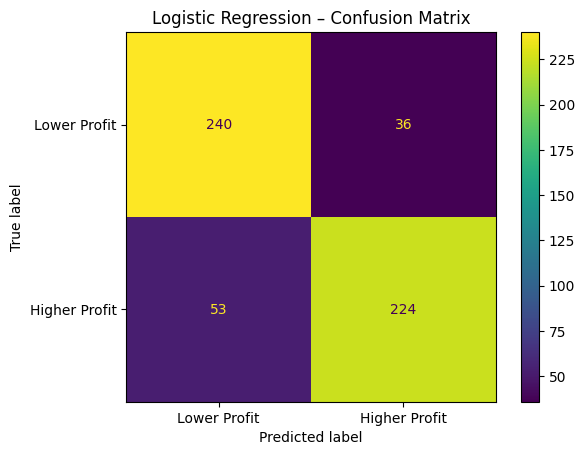

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Lower Profit", "Higher Profit"]
)

disp.plot()

plt.title("Logistic Regression – Confusion Matrix")
plt.show()

## Final Regression Model Comparison

All seven regression models were trained using the same training data,
testing data, and 26 predictor features.

The models are compared using MAE, MSE, RMSE, and R².

For MAE, MSE, and RMSE:
Lower values indicate smaller prediction errors.

For R²:
Higher values indicate that the model explains more variation in Profit.

The comparison helps identify which model performed strongest on the
unseen test data.

In [45]:
comparison_sorted = comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_sorted

,Model,MAE,MSE,RMSE,R2
0,Boosting Regression,391.869779,7.827151e+05,884.711883,0.828539
1,Random Forest Regression,390.904167,1.014776e+06,1007.360878,0.777704
2,Bagging Regression,395.483892,1.066924e+06,1032.920360,0.766280
3,Linear Regression,615.228250,1.169603e+06,1081.481652,0.743788
4,Decision Tree Regression,544.491989,1.732436e+06,1316.220464,0.620494
5,KNN Regression,761.175298,2.269866e+06,1506.607529,0.502765
6,SVR,966.471751,4.908289e+06,2215.465909,-0.075205


## Regression Model Performance Comparison

The following chart compares the R² scores of all seven regression models.

A higher R² indicates that the model explains more variation in the Profit
target on the test data.

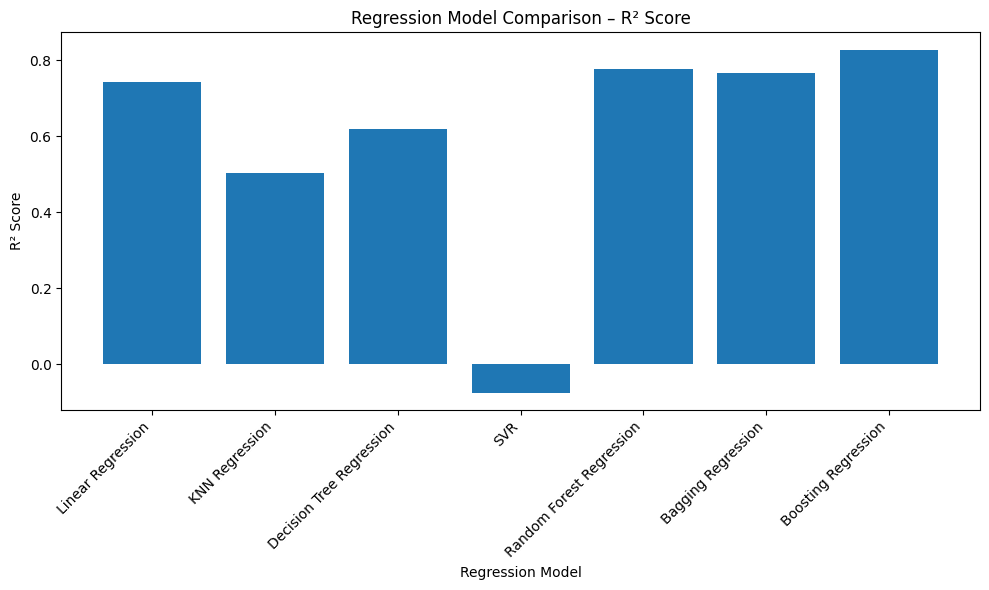

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison – R² Score")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Feature Impact Analysis

The same 26 predictor features were used for all regression models.

Instead of automatically removing weak features, we test how much each
feature contributes to the final Boosting Regression model.

Permutation Importance measures how much the model performance decreases
when a feature's values are randomly shuffled.

A larger importance value means the model relies more on that feature.

This analysis is used to understand feature contribution, not to
automatically remove features.

In [48]:
from sklearn.inspection import permutation_importance

# Convert sparse matrix to dense array
X_test_dense = X_test_processed.toarray()

feature_importance = permutation_importance(
    boosting_model,
    X_test_dense,
    y_test,
    n_repeats=5,
    random_state=34,
    scoring="r2"
)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance
0,numerical__Unit_Price,1.387390
1,numerical__Quantity,0.295909
2,numerical__Discount_Pct,0.037198
3,categorical__Order_Status_Delivered,0.014244
4,numerical__Order_Day,0.004970
5,numerical__Website_Session_Minutes,0.001856
6,categorical__Order_Status_Delayed,0.000991
7,numerical__Order_Month,0.000875
8,categorical__Device_Desktop,0.000817
9,numerical__Items_Viewed,0.000798


## Final Conclusion

The objective of this project was to predict the Profit generated from
an e-commerce transaction using customer, product, order, marketing,
and operational information.

After data understanding and EDA, duplicate records were removed and
missing values were handled using appropriate preprocessing techniques.
Categorical variables were encoded and numerical variables were scaled.

Seven regression models were evaluated using the same feature set.

Among the tested regression models, Boosting Regression achieved the
highest R² score of 0.829 and the lowest RMSE of 884.71.
Random Forest had the lowest MAE of 390.90.

Feature impact analysis showed that Unit_Price and Quantity had the
largest contribution to the Boosting model, followed by Discount_Pct.
The remaining features had smaller individual impacts, so they were
not removed automatically.

Logistic Regression was also used to classify transactions into
Lower Profit and Higher Profit categories. It achieved an accuracy
of 83.91%, with an F1-score of 83.43%.

Overall, the project demonstrates the complete machine learning
workflow from data understanding and EDA to preprocessing, model
training, evaluation, feature impact analysis, and final comparison.

In [49]:
# Final Regression Results
comparison_sorted

,Model,MAE,MSE,RMSE,R2
0,Boosting Regression,391.869779,7.827151e+05,884.711883,0.828539
1,Random Forest Regression,390.904167,1.014776e+06,1007.360878,0.777704
2,Bagging Regression,395.483892,1.066924e+06,1032.920360,0.766280
3,Linear Regression,615.228250,1.169603e+06,1081.481652,0.743788
4,Decision Tree Regression,544.491989,1.732436e+06,1316.220464,0.620494
5,KNN Regression,761.175298,2.269866e+06,1506.607529,0.502765
6,SVR,966.471751,4.908289e+06,2215.465909,-0.075205


## Actual vs Predicted Profit

This comparison shows the actual Profit values from the test dataset
against the Profit values predicted by the Boosting Regression model.

The purpose is to visually understand how closely the predicted values
match the actual values.

In [50]:
# Create Actual vs Predicted table

actual_vs_predicted = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred_boosting
})

actual_vs_predicted.head(20)

,Actual Profit,Predicted Profit
0,609.88,698.697920
1,2226.03,2499.977251
2,1128.65,970.839491
3,279.34,344.852558
4,2836.66,2976.771921
5,142.03,127.842800
6,706.89,706.827280
7,200.55,454.574795
8,594.00,453.946834
9,453.49,1068.392920
